# Pipeline Penambangan Teks Berita: Klasifikasi Detikcom (Sport vs Finance)

Dokumen *Jupyter Notebook* ini menyajikan alur lengkap (*end-to-end pipeline*) penambangan data web (**Web Content Mining**) pada portal berita **Detikcom**:

```
[Hasil Scraping Detikcom (778 Berita)] 
       │
       ▼
[1. Cleansing & Seleksi Data] ──────────► Deteksi Nilai Kosong & Seleksi Top-100 Berita Terpanjang per Kategori (Total 200)
       │
       ▼
[2. Text Preprocessing NLP] ────────────► Regex Cleaning ──► Case Folding ──► Sastrawi Stopwords ──► Sastrawi Stemming
       │
       ▼
[3. Ekstraksi Fitur (TF-IDF & N-Gram)] ─► Matriks DTM (200 x 6.486) & Analisis Frasa Majemuk (Bigram)
       │
       ▼
[4. Reduksi Dimensi & Clustering] ──────► PCA (100 Komponen Utama) & K-Means Unsupervised Clustering (Silhouette Score)
       │
       ▼
[5. Supervised Machine Learning] ───────► Komparasi 5 Algoritma x 2 Representasi Fitur (TF-IDF vs PCA) + 5-Fold CV
       │
       ▼
[6. Evaluasi & Inferensi Interaktif] ───► Grouped Bar Chart, Confusion Matrix, & Fungsi Prediksi Berita Baru
```

## 1. Setup Lingkungan & Import Library Terpusat
Seluruh modul data science, pemrosesan bahasa alami (NLP), reduksi dimensi, pengelompokan tanpa pengawasan (*clustering*), serta model klasifikasi di-import di awal secara terpusat.

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from wordcloud import WordCloud

# NLP & Text Preprocessing Bahasa Indonesia (Sastrawi)
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Ekstraksi Fitur & Reduksi Dimensi
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import PCA

# Unsupervised Learning (Clustering)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Supervised Machine Learning & Validasi
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Metrik Evaluasi
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Pengaturan visualisasi grafik
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

print("✓ Seluruh library berhasil dimuat dengan sukses.")

✓ Seluruh library berhasil dimuat dengan sukses.


## 2. Pemuatan Dataset Mentah (Raw Scraped Data)
Memuat dataset berita mentah hasil scraping dari berkas `hasil_scraping_detik_sport.csv` dan `hasil_scraping_detik_finance.csv`.

In [2]:
df_sport_raw = pd.read_csv('hasil_scraping_detik_sport.csv')
df_finance_raw = pd.read_csv('hasil_scraping_detik_finance.csv')

print(f"Dataset Detik Sport   : {df_sport_raw.shape[0]} artikel, {df_sport_raw.shape[1]} kolom")
print(f"Dataset Detik Finance : {df_finance_raw.shape[0]} artikel, {df_finance_raw.shape[1]} kolom")

print("\n--- Contoh 2 Data Teratas Detik Sport ---")
display(df_sport_raw.head(2))

print("\n--- Contoh 2 Data Teratas Detik Finance ---")
display(df_finance_raw.head(2))

Dataset Detik Sport   : 392 artikel, 4 kolom
Dataset Detik Finance : 386 artikel, 4 kolom

--- Contoh 2 Data Teratas Detik Sport ---


,judul,link,waktu,isi_berita
0,Men's World Tennis Championship: Rifqi dan Raf...,https://sport.detik.com/raket/d-8656258/mens-w...,"Kamis, 10 Sep 2026 04:42 WIB","Dua petenis Indonesia,Muhammad Rifqi Fitriadid..."
1,Kevin Sanjaya Antusias Lihat Semangat Talenta ...,https://sport.detik.com/raket/d-8656218/kevin-...,"Kamis, 10 Sep 2026 01:15 WIB",Audisi Umum PB Djarum 2026 sedang berlangsung ...



--- Contoh 2 Data Teratas Detik Finance ---


,judul,link,waktu,isi_berita
0,"Video: 4,5 Juta Keluarga Ajukan Diri untuk Dap...",https://20.detik.com/detikupdate/20260908-2609...,NaN,NaN
1,Video: BPS Tegaskan Desil Tak Hanya Berdasarka...,https://20.detik.com/detikupdate/20260908-2609...,NaN,NaN


# 2. Pemeriksaan & Seleksi Data (Cleansing & Selection)

### 2.1 Deteksi Missing Values & String Kosong
Pemeriksaan dilakukan terhadap nilai `NaN`, `None`, atau teks kosong yang hanya berisi karakter spasi/whitespace.

In [3]:
def cek_data_kosong(df, nama_df="DataFrame"):
    hasil = []
    for col in df.columns:
        null_count = df[col].isna().sum()
        if df[col].dtype == 'object':
            empty_str = (df[col].fillna('').astype(str).str.strip() == '').sum() - null_count
        else:
            empty_str = 0
        total_kosong = null_count + empty_str
        pct = (total_kosong / len(df)) * 100
        hasil.append({
            'Kolom': col,
            'Null / NaN': null_count,
            'String Kosong': empty_str,
            'Total Kosong': total_kosong,
            'Persentase (%)': round(pct, 2)
        })
    print(f"=== Ringkasan Data Kosong: {nama_df} ===")
    return pd.DataFrame(hasil)

display(cek_data_kosong(df_sport_raw, "Detik Sport"))
display(cek_data_kosong(df_finance_raw, "Detik Finance"))

=== Ringkasan Data Kosong: Detik Sport ===


,Kolom,Null / NaN,String Kosong,Total Kosong,Persentase (%)
0,judul,0,0,0,0.0
1,link,0,0,0,0.0
2,waktu,0,0,0,0.0
3,isi_berita,0,0,0,0.0


=== Ringkasan Data Kosong: Detik Finance ===


,Kolom,Null / NaN,String Kosong,Total Kosong,Persentase (%)
0,judul,0,0,0,0.00
1,link,0,0,0,0.00
2,waktu,3,0,3,0.78
3,isi_berita,3,0,3,0.78


In [4]:
# Menghapus baris yang memiliki nilai kosong pada judul atau isi_berita
df_sport = (
    df_sport_raw.replace(r'^\s*$', np.nan, regex=True)
    .dropna(subset=['judul', 'isi_berita'])
    .reset_index(drop=True)
)

df_finance = (
    df_finance_raw.replace(r'^\s*$', np.nan, regex=True)
    .dropna(subset=['judul', 'isi_berita'])
    .reset_index(drop=True)
)

print(f"Data Bersih Sport   : {len(df_sport)} baris")
print(f"Data Bersih Finance : {len(df_finance)} baris")

Data Bersih Sport   : 392 baris
Data Bersih Finance : 383 baris


### 2.2 Verifikasi Duplikasi Data
Memastikan tidak ada artikel yang memiliki pasangan judul dan isi berita yang sama.

In [5]:
dup_sport = df_sport.duplicated(subset=['judul', 'isi_berita']).sum()
dup_fin = df_finance.duplicated(subset=['judul', 'isi_berita']).sum()

print(f"Duplikat pada Detik Sport   : {dup_sport} artikel")
print(f"Duplikat pada Detik Finance : {dup_fin} artikel")

Duplikat pada Detik Sport   : 0 artikel
Duplikat pada Detik Finance : 0 artikel


### 2.3 Seleksi Top-100 Berita Terpanjang (Balanced Sampling)
Dikarenakan total scraping menghasilkan 778 artikel, kita menyeleksi **100 artikel dengan jumlah kata terbanyak** dari masing-masing kategori:
- **Tujuan**: Memastikan setiap dokumen memiliki konteks teks yang kaya dan representatif untuk analisis semantik.
- **Keseimbangan Kelas**: Membentuk dataset seimbang (*balanced classes*) dengan rasio 50% Sport (100 artikel) dan 50% Finance (100 artikel) = **Total 200 artikel**.

In [6]:
# Menghitung panjang kata pada artikel
df_sport['word_count'] = df_sport['isi_berita'].astype(str).str.split().str.len()
df_finance['word_count'] = df_finance['isi_berita'].astype(str).str.split().str.len()

# Mengambil 100 artikel teratas per kategori
df_sport_100 = df_sport.nlargest(100, 'word_count').copy().reset_index(drop=True)
df_finance_100 = df_finance.nlargest(100, 'word_count').copy().reset_index(drop=True)

# Pemberian label kelas target
df_sport_100['kategori'] = 'sport'
df_finance_100['kategori'] = 'finance'

# Penggabungan menjadi satu kesatuan dataset
df = pd.concat([df_sport_100, df_finance_100], ignore_index=True)

print("=== Statistik Dataset Terpilih ===")
print(df['kategori'].value_counts())
print(f"Panjang kata Sport   : min = {df_sport_100['word_count'].min()}, max = {df_sport_100['word_count'].max()} kata")
print(f"Panjang kata Finance : min = {df_finance_100['word_count'].min()}, max = {df_finance_100['word_count'].max()} kata")
display(df[['judul', 'kategori', 'word_count']].head(4))

=== Statistik Dataset Terpilih ===
kategori
sport      100
finance    100
Name: count, dtype: int64
Panjang kata Sport   : min = 357, max = 821 kata
Panjang kata Finance : min = 395, max = 1237 kata


,judul,kategori,word_count
0,"SARGA.CO Gelar IHR Merdeka Cup 2026, Total Had...",sport,821
1,"IHR Merdeka Cup 2026 Digelar, 18 Ribu Penonton...",sport,799
2,"Akademi Dewa United Punya Markas Baru, Demi Ma...",sport,736
3,Duet Pegolf Indonesia-Thailand Juara The Indon...,sport,719


# 3. Pembersihan Teks & NLP Preprocessing (Text Preprocessing)

Proses penyiapan teks mentah (*raw text*) menjadi bentuk leksikal terstruktur:
1. **Noise Removal**: Menghilangkan widget `[Gambas:...]`, rekomendasi baca ("Baca juga:", "Lihat juga Video:"), watermark portal ("detikcom", "detikSport", "detikFinance"), dan prefix kota berita ("Jakarta - ").
2. **Case Folding & Sanitasi**: Menyeragamkan seluruh huruf menjadi huruf kecil (*lowercase*) serta membuang angka, tanda baca, dan karakter non-alfabet.
3. **Stopword Removal**: Menghilangkan kata tugas umum Bahasa Indonesia (seperti *dan, yang, di, ke, dari, pada*) menggunakan `Sastrawi.StopWordRemover`.
4. **Stemming (Sastrawi)**: Mengubah kata berimbuhan (prefiks, sufiks, konfiks) kembali ke bentuk kata dasarnya.

In [7]:
def hitung_statistik_kata(series_teks):
    """Menghitung total kemunculan token kata dan jumlah kosakata unik."""
    gabungan = series_teks.astype(str).str.lower().str.cat(sep=' ')
    semua_kata = re.findall(r'(?u)\b\w\w+\b', gabungan)
    kata_unik = set(semua_kata)
    return len(semua_kata), len(kata_unik)

total_awal, unik_awal = hitung_statistik_kata(df['isi_berita'])
print(f"[Tahap 0: Teks Asli] Total Kata: {total_awal:,} | Kata Unik (Vocab): {unik_awal:,}")

[Tahap 0: Teks Asli] Total Kata: 104,889 | Kata Unik (Vocab): 9,674


In [8]:
def bersihkan_noise_teks(text):
    # 1. Hapus tag [Gambas:...] dan widget video
    text = re.sub(r"\[Gambas:.*?\]", " ", text)
    # 2. Hapus baris rekomendasi redaksi
    text = re.sub(r"(Lihat juga Video:|Baca juga:).*?(\n|$)", " ", text)
    # 3. Hapus prefix kota berita seperti "Jakarta - " atau "Bandung -"
    text = re.sub(r"^[A-Z\s]+-\s*", " ", text)
    # 4. Hapus watermark redaksi Detik
    text = re.sub(r"detikcom|detikSport|detikFinance", " ", text, flags=re.IGNORECASE)
    # 5. Case folding ke lowercase
    text = text.lower()
    # 6. Hapus karakter non-alfabet (angka & tanda baca)
    text = re.sub(r"[^a-z\s]", " ", text)
    # 7. Normalisasi spasi ganda
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['isi_berita_clean'] = df['isi_berita'].apply(bersihkan_noise_teks)
total_clean, unik_clean = hitung_statistik_kata(df['isi_berita_clean'])
print(f"[Tahap 1: Noise Cleaning & Case Folding] Total Kata: {total_clean:,} | Kata Unik: {unik_clean:,}")

[Tahap 1: Noise Cleaning & Case Folding] Total Kata: 101,479 | Kata Unik: 9,076


In [9]:
# Inisialisasi Stopword Remover dan Stemmer Sastrawi
stop_factory = StopWordRemoverFactory()
stopword_remover = stop_factory.create_stop_word_remover()

stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def stopword_dan_stemming(text):
    text = stopword_remover.remove(text)
    text = stemmer.stem(text)
    return text

file_processed = Path("data_berita_processed.csv")

# Mekanisme Caching untuk efisiensi komputasi
if file_processed.is_file():
    print(f"✓ Berkas cache '{file_processed}' ditemukan. Memuat data yang telah di-stem...")
    df_cached = pd.read_csv(file_processed)
    df['isi_berita_stemmed'] = df_cached['isi_berita']
else:
    print("Menjalankan Stopword Removal & Stemming menggunakan Sastrawi...")
    df['isi_berita_stemmed'] = df['isi_berita_clean'].apply(stopword_dan_stemming)
    
    # Simpan hasil untuk sesi berikutnya
    df_export = df[['judul', 'link', 'waktu', 'isi_berita_stemmed', 'kategori']].rename(
        columns={'isi_berita_stemmed': 'isi_berita'}
    )
    df_export.to_csv(file_processed, index=False, encoding="utf-8-sig")
    print(f"✓ Berkas berhasil disimpan ke '{file_processed}'.")

total_stem, unik_stem = hitung_statistik_kata(df['isi_berita_stemmed'])
print(f"[Tahap 2: Stopwords & Stemming Sastrawi] Total Kata: {total_stem:,} | Kata Unik: {unik_stem:,}")

✓ Berkas cache 'data_berita_processed.csv' ditemukan. Memuat data yang telah di-stem...
[Tahap 2: Stopwords & Stemming Sastrawi] Total Kata: 79,781 | Kata Unik: 6,486


### 3.1 Evaluasi Hasil Preprocessing & Visualisasi WordCloud
Melihat perbandingan tingkat reduksi kata serta visualisasi kata-kata dominan pada masing-masing kategori.

In [10]:
# Tabel Rekapitulasi Reduksi Dimensi Teks
df_reduksi = pd.DataFrame([
    {'Tahapan': '1. Teks Asli (Raw Scraped)', 'Total Token': total_awal, 'Kata Unik (Vocab)': unik_awal},
    {'Tahapan': '2. Noise Cleaning & Case Folding', 'Total Token': total_clean, 'Kata Unik (Vocab)': unik_clean},
    {'Tahapan': '3. Stopwords Removal & Stemming Sastrawi', 'Total Token': total_stem, 'Kata Unik (Vocab)': unik_stem},
])
df_reduksi['Reduksi Token (%)'] = round((1 - df_reduksi['Total Token'] / total_awal) * 100, 2)
df_reduksi['Reduksi Vocab (%)'] = round((1 - df_reduksi['Kata Unik (Vocab)'] / unik_awal) * 100, 2)

display(df_reduksi)

,Tahapan,Total Token,Kata Unik (Vocab),Reduksi Token (%),Reduksi Vocab (%)
0,1. Teks Asli (Raw Scraped),104889,9674,0.00,0.00
1,2. Noise Cleaning & Case Folding,101479,9076,3.25,6.18
2,3. Stopwords Removal & Stemming Sastrawi,79781,6486,23.94,32.95


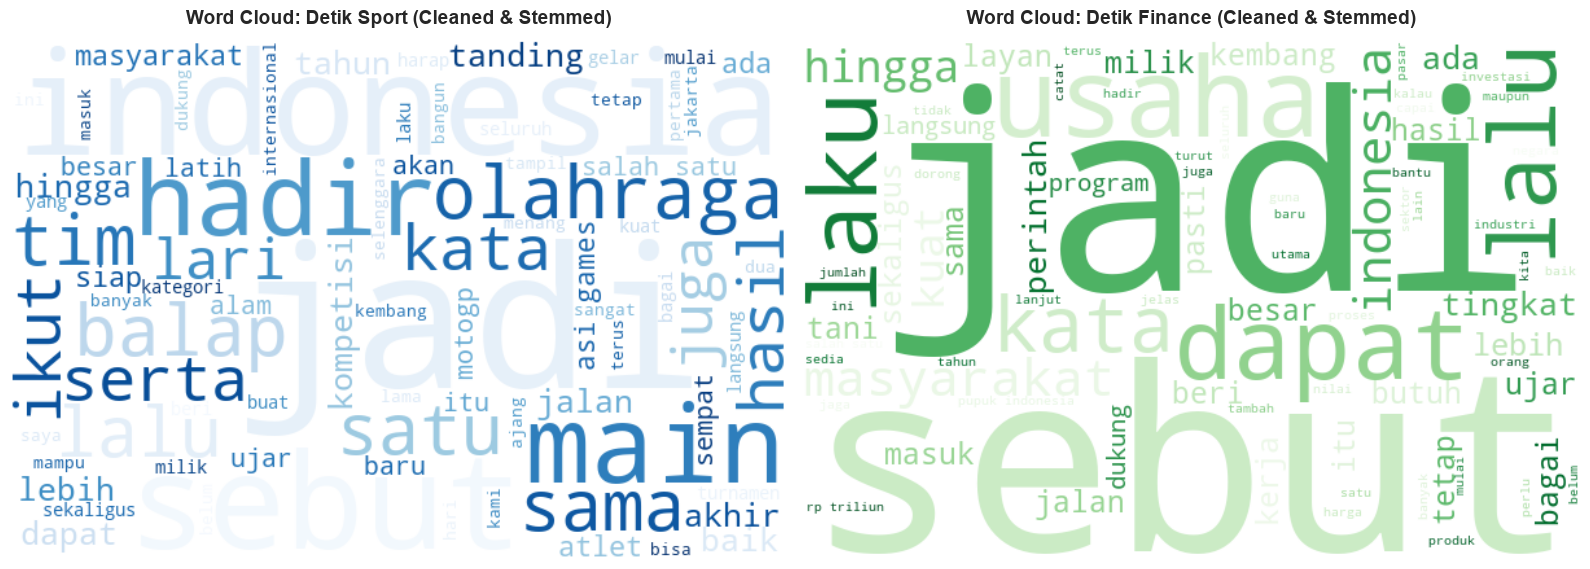

In [11]:
# Visualisasi WordCloud Komparatif: Detik Sport vs Detik Finance
teks_sport = " ".join(df[df['kategori'] == 'sport']['isi_berita_stemmed'].dropna())
teks_finance = " ".join(df[df['kategori'] == 'finance']['isi_berita_stemmed'].dropna())

wc_sport = WordCloud(
    width=600, height=400, background_color='white', colormap='Blues', max_words=80, random_state=42
).generate(teks_sport)

wc_finance = WordCloud(
    width=600, height=400, background_color='white', colormap='Greens', max_words=80, random_state=42
).generate(teks_finance)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].imshow(wc_sport, interpolation='bilinear')
axes[0].set_title('Word Cloud: Detik Sport (Cleaned & Stemmed)', fontsize=14, fontweight='bold', pad=12)
axes[0].axis('off')

axes[1].imshow(wc_finance, interpolation='bilinear')
axes[1].set_title('Word Cloud: Detik Finance (Cleaned & Stemmed)', fontsize=14, fontweight='bold', pad=12)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# 4. Ekstraksi Fitur Teks: TF-IDF & Analisis Frasa N-Gram (Bigram)

### 4.1 Pembobotan Kata (TF-IDF Vectorization)
Menghitung relevansi leksikal kata tunggal (*unigram*) terhadap dokumen:
$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

In [12]:
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df['isi_berita_stemmed'].astype(str))

vocab_names = vectorizer.get_feature_names_out()
print(f"Dimensi Matriks TF-IDF: {tfidf_matrix.shape[0]} Dokumen × {tfidf_matrix.shape[1]} Fitur Kata")

df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=vocab_names)

# Simpan dataset hasil pembobotan TF-IDF
df_tfidf_export = df_tfidf.copy()
df_tfidf_export.insert(0, 'kategori_label', df['kategori'].values)
df_tfidf_export.to_csv('data_tfidf.csv', index=False)
print("✓ Berkas TF-IDF berhasil disimpan ke data_tfidf.csv")

display(df_tfidf.head(3))

Dimensi Matriks TF-IDF: 200 Dokumen × 6486 Fitur Kata
✓ Berkas TF-IDF berhasil disimpan ke data_tfidf.csv


,aa,aadi,aam,aaron,aau,ab,abai,abdi,abdu,abdul,...,zarco,zhang,zigmars,zon,zona,zone,zulhas,zulkifli,zumba,zwinkle
0,0.0,0.0,0.0,0.0,0.0,0.024163,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


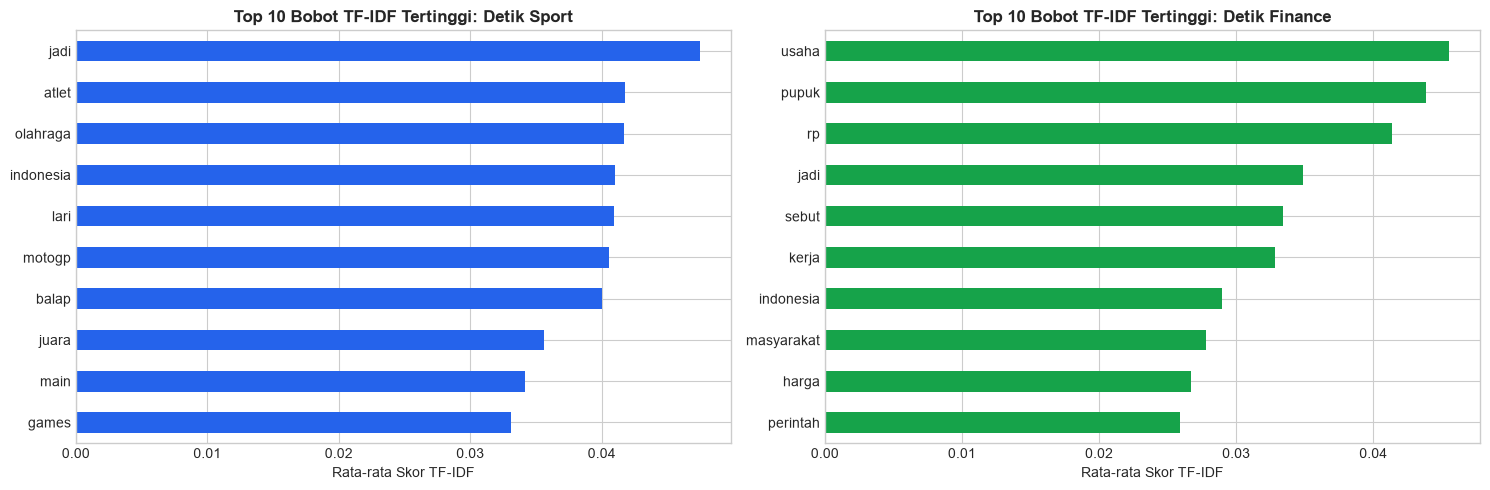

In [13]:
# Analisis 10 Kata dengan Skor TF-IDF Rata-rata Tertinggi per Kategori
df_tfidf_cat = df_tfidf.copy()
df_tfidf_cat['__kategori__'] = df['kategori'].values

mean_sport = df_tfidf_cat[df_tfidf_cat['__kategori__'] == 'sport'].drop('__kategori__', axis=1).mean().nlargest(10)
mean_fin = df_tfidf_cat[df_tfidf_cat['__kategori__'] == 'finance'].drop('__kategori__', axis=1).mean().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mean_sport.sort_values().plot(kind='barh', ax=axes[0], color='#2563eb')
axes[0].set_title('Top 10 Bobot TF-IDF Tertinggi: Detik Sport', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rata-rata Skor TF-IDF')

mean_fin.sort_values().plot(kind='barh', ax=axes[1], color='#16a34a')
axes[1].set_title('Top 10 Bobot TF-IDF Tertinggi: Detik Finance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rata-rata Skor TF-IDF')

plt.tight_layout()
plt.show()

### 4.2 Analisis Frasa N-Gram (Bigram)
Kata tunggal (*unigram*) terkadang kehilangan makna konteks. Ekstraksi frasa 2 kata (*bigram*) menggunakan `CountVectorizer(ngram_range=(2, 2))` mampu menangkap entitas majemuk penting seperti *"asi games"*, *"juara dunia"*, *"pupuk indonesia"*, dan *"upah minimum"*.

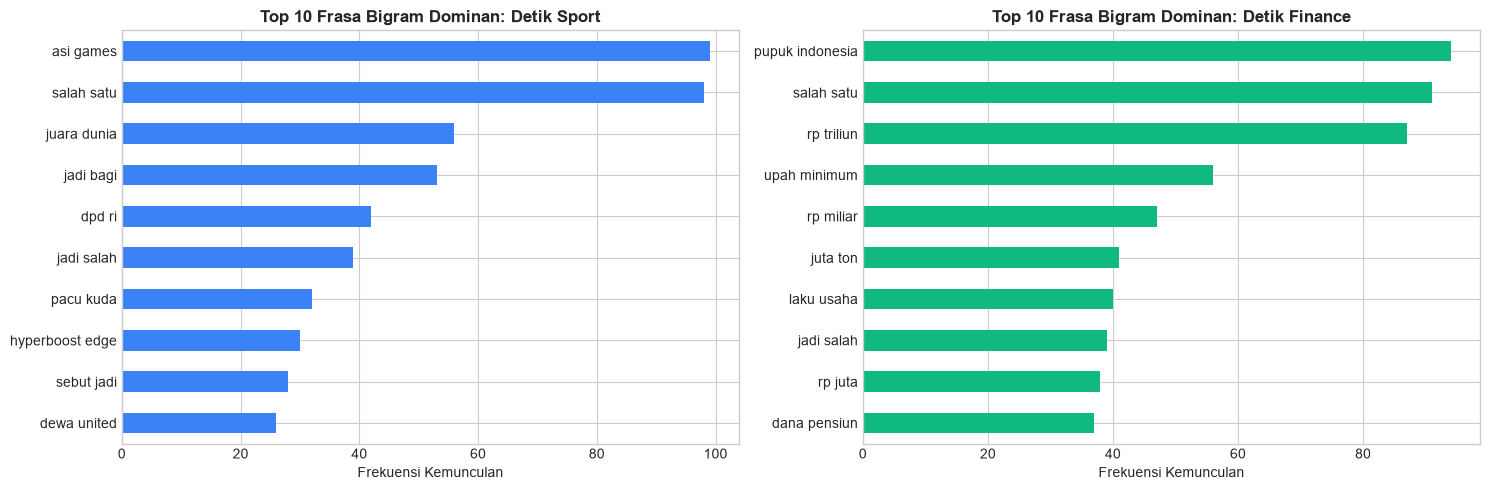

In [14]:
# Ekstraksi Frasa 2 Kata (Bigram)
bigram_vec = CountVectorizer(ngram_range=(2, 2))
bigram_matrix = bigram_vec.fit_transform(df['isi_berita_stemmed'].astype(str))
bigram_names = bigram_vec.get_feature_names_out()

df_bigram = pd.DataFrame(bigram_matrix.toarray(), columns=bigram_names)
df_bigram['__kategori__'] = df['kategori'].values

top_bg_sport = df_bigram[df_bigram['__kategori__'] == 'sport'].drop('__kategori__', axis=1).sum().nlargest(10)
top_bg_finance = df_bigram[df_bigram['__kategori__'] == 'finance'].drop('__kategori__', axis=1).sum().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_bg_sport.sort_values().plot(kind='barh', ax=axes[0], color='#3b82f6')
axes[0].set_title('Top 10 Frasa Bigram Dominan: Detik Sport', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Frekuensi Kemunculan')

top_bg_finance.sort_values().plot(kind='barh', ax=axes[1], color='#10b981')
axes[1].set_title('Top 10 Frasa Bigram Dominan: Detik Finance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Frekuensi Kemunculan')

plt.tight_layout()
plt.show()

# 5. Reduksi Dimensi (PCA) & Penambangan Pola Tanpa Pengawasan (K-Means)

### 5.1 Reduksi Dimensi Menggunakan PCA (Principal Component Analysis)
Matriks TF-IDF memiliki 6.486 fitur kata. PCA mereduksi dimensi menjadi **100 komponen utama (PC1 - PC100)** ortogonal yang mempertahankan variansi informasi maksimal.

In [15]:
n_components = 100
pca = PCA(n_components=n_components, random_state=42)
pca_result = pca.fit_transform(tfidf_matrix.toarray())

total_varians = pca.explained_variance_ratio_.sum() * 100
print(f"Dimensi Awal Matriks TF-IDF : {tfidf_matrix.shape}")
print(f"Dimensi Setelah Reduksi PCA : {pca_result.shape}")
print(f"Total Varians yang Dipertahankan: {total_varians:.2f}%")

kolom_pc = [f"PC{i+1}" for i in range(n_components)]
df_pca = pd.DataFrame(pca_result, columns=kolom_pc)
df_pca.insert(0, 'kategori_label', df['kategori'].values)

# Simpan dataset hasil reduksi dimensi PCA
df_pca.to_csv("data_hasil_pca.csv", index=False)
display(df_pca.head(3))

Dimensi Awal Matriks TF-IDF : (200, 6486)
Dimensi Setelah Reduksi PCA : (200, 100)
Total Varians yang Dipertahankan: 74.69%


,kategori_label,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,...,PC91,PC92,PC93,PC94,PC95,PC96,PC97,PC98,PC99,PC100
0,sport,-0.071780,-0.064199,-0.080238,0.116040,-0.031971,0.295027,0.063424,0.165786,0.182133,...,0.010853,0.007050,-0.022169,-0.002590,0.004471,0.006671,0.007957,0.014396,-0.028863,0.014913
1,sport,-0.078868,0.000701,-0.024530,0.089745,-0.054959,0.261947,0.029761,0.155310,0.169747,...,-0.022078,-0.012897,0.018607,-0.002274,-0.003747,0.005807,0.013712,0.014098,0.002080,-0.014349
2,sport,-0.070881,0.055971,-0.089990,-0.010246,-0.022041,-0.009665,0.004084,-0.014059,-0.042880,...,-0.000799,-0.025188,-0.015448,-0.036495,-0.064679,0.046136,-0.003086,-0.018930,0.002688,-0.046138


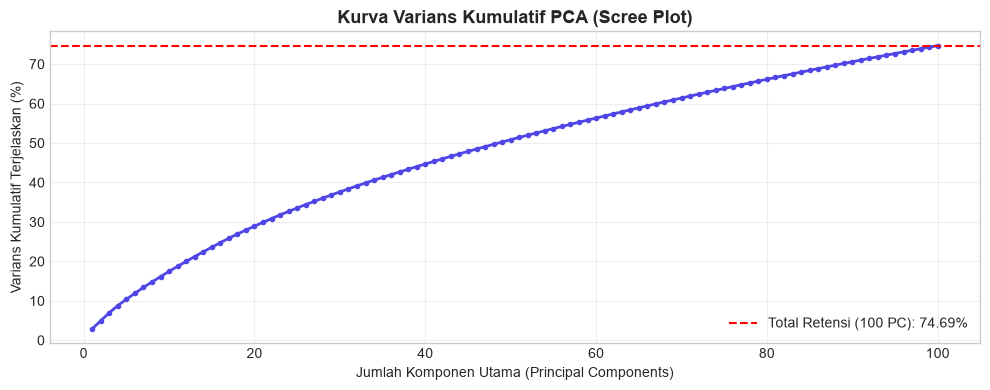

In [16]:
# Visualisasi Scree Plot & Varians Kumulatif PCA
cum_var = np.cumsum(pca.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 4))
plt.plot(range(1, n_components + 1), cum_var, marker='o', markersize=3, color='#4f46e5', linewidth=2)
plt.axhline(y=total_varians, color='r', linestyle='--', label=f'Total Retensi ({n_components} PC): {total_varians:.2f}%')
plt.title('Kurva Varians Kumulatif PCA (Scree Plot)', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Komponen Utama (Principal Components)')
plt.ylabel('Varians Kumulatif Terjelaskan (%)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 Penambangan Pola Tanpa Pengawasan: K-Means Clustering
Model **K-Means Clustering** dijalankan pada fitur PCA ($k=2$) secara murni tanpa melihat label kategori (*unsupervised*). Evaluasi dilakukan dengan:
- **Silhouette Score**: Mengukur kerapatan dan pemisahan antar klaster (rentang -1 hingga +1).
- **Davies-Bouldin Index**: Mengukur rasio jarak intra-klaster terhadap jarak antar-klaster (semakin kecil semakin baik).
- **Purity / Kesesuaian Klaster**: Membandingkan hasil klaster alami dengan ground truth.

In [17]:
# Inisialisasi K-Means dengan k=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(pca_result)

sil_score = silhouette_score(pca_result, cluster_labels)
db_score = davies_bouldin_score(pca_result, cluster_labels)

print(f"Silhouette Score    : {sil_score:.4f}")
print(f"Davies-Bouldin Index: {db_score:.4f}")

# Tabel Kontinjensi: Klaster vs Label Aktual
df_eval_cluster = pd.crosstab(
    df['kategori'],
    cluster_labels,
    rownames=['Aktual (Ground Truth)'],
    colnames=['Klaster K-Means']
)
display(df_eval_cluster)

# Hitung Akurasi Kemurnian Klaster (Purity)
purity = (df_eval_cluster.iloc[0, 1] + df_eval_cluster.iloc[1, 0]) / len(df) * 100
if purity < 50:
    purity = 100 - purity
print(f"Tingkat Kemurnian Klaster Alami (Clustering Purity): {purity:.1f}%")

Silhouette Score    : 0.0259
Davies-Bouldin Index: 5.8830


Klaster K-Means,0,1
Aktual (Ground Truth),,
finance,4,96
sport,93,7


Tingkat Kemurnian Klaster Alami (Clustering Purity): 94.5%


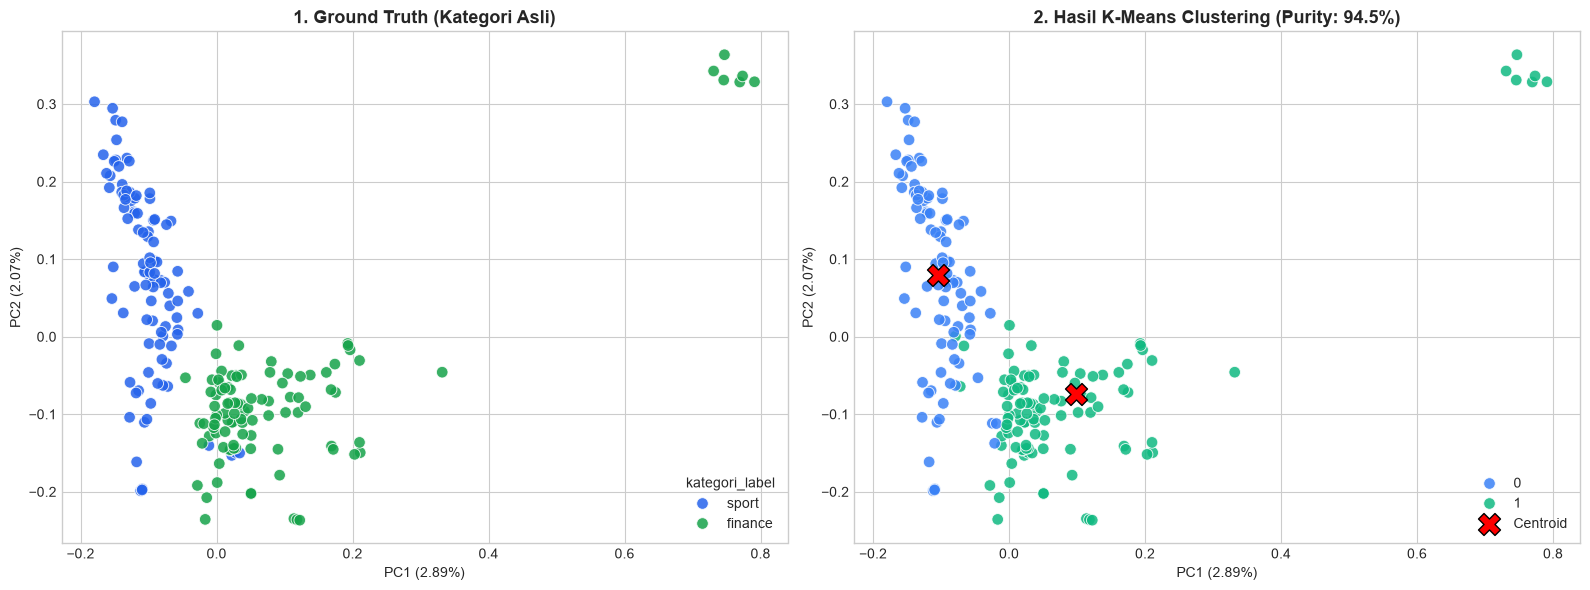

In [18]:
# Visualisasi Scatter Plot 2D: Ground Truth vs Hasil K-Means Clustering
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Ground Truth
sns.scatterplot(
    x=df_pca['PC1'], y=df_pca['PC2'], hue=df_pca['kategori_label'],
    palette={'sport': '#2563eb', 'finance': '#16a34a'}, s=70, alpha=0.85, ax=axes[0]
)
axes[0].set_title('1. Ground Truth (Kategori Asli)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')

# Plot 2: K-Means Clusters
sns.scatterplot(
    x=df_pca['PC1'], y=df_pca['PC2'], hue=cluster_labels,
    palette=['#3b82f6', '#10b981'], s=70, alpha=0.85, ax=axes[1]
)
# Titik Centroid K-Means
axes[1].scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    s=250, c='red', marker='X', edgecolors='black', label='Centroid'
)
axes[1].set_title(f'2. Hasil K-Means Clustering (Purity: {purity:.1f}%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 6. Pemodelan Machine Learning: Komparasi 5 Algoritma pada TF-IDF vs PCA

Melatih dan menguji **5 algoritma Machine Learning** dari paradigma yang beragam:
1. **Naive Bayes** (`MultinomialNB` pada TF-IDF, `GaussianNB` pada PCA)
2. **Logistic Regression** (Linear Probabilistic Classifier)
3. **Linear Support Vector Machine (LinearSVM)** (Maximum Margin Classifier)
4. **Random Forest** (Non-linear Ensemble Bagging)
5. **K-Nearest Neighbors (KNN)** (Distance-based Instance Classifier, $k=5$)

Setiap model diuji pada **dua representasi fitur**:
- **Fitur TF-IDF**: Matriks jarang berdimensi tinggi ($200 \times 6.486$).
- **Fitur PCA**: Matriks padat tereduksi 100 komponen utama ($200 \times 100$).

In [19]:
# 1. Label Encoding: Sport = 1, Finance = 0
y = df['kategori'].map({'sport': 1, 'finance': 0}).values
X_tfidf = tfidf_matrix
X_pca = pca_result

# 2. Stratified Train-Test Split (80% Train, 20% Test)
X_train_tf, X_test_tf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

X_train_pca, X_test_pca, _, _ = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# 3. K-Fold Cross Validation Setup (5-Fold Stratified)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Data Latih : {len(y_train)} sampel ({np.bincount(y_train)[0]} Finance, {np.bincount(y_train)[1]} Sport)")
print(f"Data Uji   : {len(y_test)} sampel ({np.bincount(y_test)[0]} Finance, {np.bincount(y_test)[1]} Sport)")

Data Latih : 160 sampel (80 Finance, 80 Sport)
Data Uji   : 40 sampel (20 Finance, 20 Sport)


In [20]:
# Definisi 5 Model Machine Learning untuk TF-IDF dan PCA
model_definitions = [
    ('Naive Bayes', MultinomialNB(), GaussianNB()),
    ('Logistic Regression', LogisticRegression(random_state=42), LogisticRegression(random_state=42)),
    ('Linear SVM', LinearSVC(random_state=42), LinearSVC(random_state=42)),
    ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42), RandomForestClassifier(n_estimators=100, random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier(n_neighbors=5), KNeighborsClassifier(n_neighbors=5))
]

results_comparison = []
trained_models = {}

for name, model_tf, model_pca in model_definitions:
    # --- A. Evaluasi pada Fitur TF-IDF ---
    model_tf.fit(X_train_tf, y_train)
    pred_tf = model_tf.predict(X_test_tf)
    acc_tf = accuracy_score(y_test, pred_tf)
    f1_tf = f1_score(y_test, pred_tf)
    cv_tf = cross_val_score(model_tf, X_tfidf, y, cv=cv_strategy, scoring='accuracy')
    
    # Simpan model untuk inferensi
    trained_models[f"{name} (TF-IDF)"] = model_tf
    
    # --- B. Evaluasi pada Fitur PCA ---
    model_pca.fit(X_train_pca, y_train)
    pred_pca = model_pca.predict(X_test_pca)
    acc_pca = accuracy_score(y_test, pred_pca)
    f1_pca = f1_score(y_test, pred_pca)
    cv_pca = cross_val_score(model_pca, X_pca, y, cv=cv_strategy, scoring='accuracy')
    
    trained_models[f"{name} (PCA)"] = model_pca
    
    # Rekapitulasi hasil
    results_comparison.append({
        'Model': name,
        'TF-IDF Test Acc (%)': round(acc_tf * 100, 2),
        'TF-IDF 5-Fold CV (%)': f"{cv_tf.mean()*100:.2f} ± {cv_tf.std()*100:.2f}",
        'TF-IDF F1-Score (%)': round(f1_tf * 100, 2),
        'PCA Test Acc (%)': round(acc_pca * 100, 2),
        'PCA 5-Fold CV (%)': f"{cv_pca.mean()*100:.2f} ± {cv_pca.std()*100:.2f}",
        'PCA F1-Score (%)': round(f1_pca * 100, 2)
    })

df_comparison = pd.DataFrame(results_comparison)
display(df_comparison)

,Model,TF-IDF Test Acc (%),TF-IDF 5-Fold CV (%),TF-IDF F1-Score (%),PCA Test Acc (%),PCA 5-Fold CV (%),PCA F1-Score (%)
0,Naive Bayes,100.0,99.00 ± 2.00,100.00,87.5,92.50 ± 3.16,88.37
1,Logistic Regression,100.0,99.00 ± 2.00,100.00,100.0,99.00 ± 2.00,100.00
2,Linear SVM,100.0,99.00 ± 2.00,100.00,100.0,99.00 ± 2.00,100.00
3,Random Forest,97.5,97.50 ± 2.74,97.44,100.0,98.50 ± 2.00,100.00
4,K-Nearest Neighbors,100.0,98.50 ± 2.00,100.00,95.0,95.00 ± 3.54,95.24


# 7. Visualisasi Hasil & Uji Prediksi Berita Baru

### 7.1 Visualisasi Grafik Komparasi Model: TF-IDF vs PCA
Memvisualisasikan skor akurasi pengujian (*Test Accuracy*) dan akurasi validasi silang (*5-Fold CV*) antara representasi TF-IDF dan PCA pada kelima model.

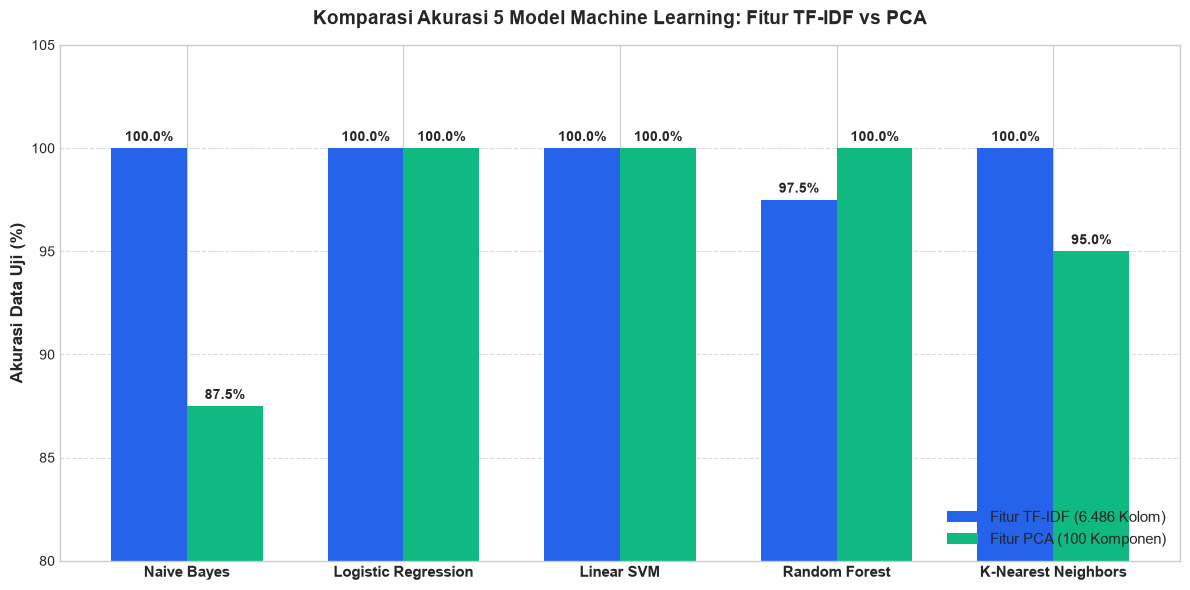

In [21]:
# Menyiapkan data numerik untuk Grouped Bar Chart
model_names = [r['Model'] for r in results_comparison]
tf_acc = [r['TF-IDF Test Acc (%)'] for r in results_comparison]
pca_acc = [r['PCA Test Acc (%)'] for r in results_comparison]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, tf_acc, width, label='Fitur TF-IDF (6.486 Kolom)', color='#2563eb')
rects2 = ax.bar(x + width/2, pca_acc, width, label='Fitur PCA (100 Komponen)', color='#10b981')

ax.set_ylabel('Akurasi Data Uji (%)', fontsize=12, fontweight='bold')
ax.set_title('Komparasi Akurasi 5 Model Machine Learning: Fitur TF-IDF vs PCA', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11, fontweight='bold')
ax.set_ylim(80, 105)
ax.legend(loc='lower right', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Label angka di atas batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

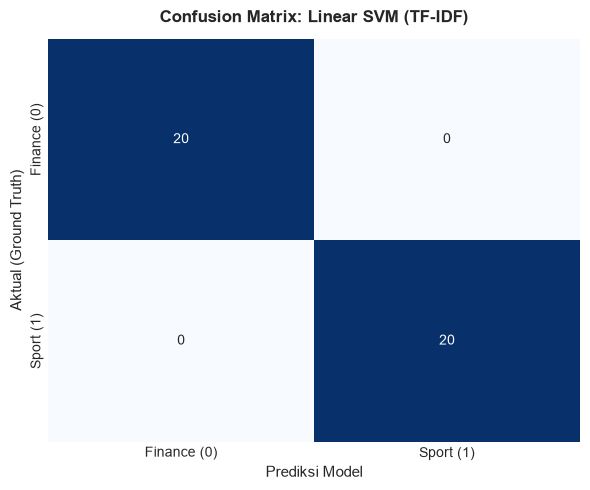

=== Laporan Klasifikasi Rinci: Linear SVM (TF-IDF) ===
              precision    recall  f1-score   support

 Finance (0)       1.00      1.00      1.00        20
   Sport (1)       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [22]:
# Visualisasi Confusion Matrix Heatmap untuk Model Terbaik (Linear SVM)
best_model_tf = trained_models['Linear SVM (TF-IDF)']
y_pred_best = best_model_tf.predict(X_test_tf)

cm = confusion_matrix(y_test, y_pred_best)
labels = ['Finance (0)', 'Sport (1)']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False)
plt.title('Confusion Matrix: Linear SVM (TF-IDF)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Prediksi Model', fontsize=11)
plt.ylabel('Aktual (Ground Truth)', fontsize=11)
plt.tight_layout()
plt.show()

print("=== Laporan Klasifikasi Rinci: Linear SVM (TF-IDF) ===")
print(classification_report(y_test, y_pred_best, target_names=['Finance (0)', 'Sport (1)']))

### 7.2 Fungsi Uji Prediksi Berita Baru (Interactive Inference)
Fungsi siap pakai untuk menguji kalimat atau paragraf berita baru secara langsung. Fungsi ini menjalankan alur preprocessing lengkap (*noise cleaning*, *case folding*, *stopword*, *stemming*), mentransformasi ke vektor TF-IDF, dan memprediksi kategori berita beserta nilai keyakinan (*confidence level*).

In [23]:
def prediksi_kategori(teks_input, model_name='Logistic Regression (TF-IDF)'):
    """
    Memprediksi kategori suatu teks berita mentah (Sport vs Finance).
    """
    model = trained_models.get(model_name)
    if model is None:
        raise ValueError(f"Model {model_name} tidak ditemukan.")
    
    # 1. Bersihkan noise & case folding
    clean_text = bersihkan_noise_teks(teks_input)
    
    # 2. Stopwords removal & stemming Sastrawi
    stemmed_text = stopword_dan_stemming(clean_text)
    
    # 3. Transformasi ke vektor TF-IDF
    vec_input = vectorizer.transform([stemmed_text])
    
    # 4. Prediksi kelas
    pred = model.predict(vec_input)[0]
    label_pred = 'Sport' if pred == 1 else 'Finance'
    
    # 5. Hitung probabilitas keyakinan jika model mendukung predict_proba
    if hasattr(model, 'predict_proba'):
        prob = model.predict_proba(vec_input)[0]
        confidence = prob[pred] * 100
    elif hasattr(model, 'decision_function'):
        df_score = model.decision_function(vec_input)[0]
        confidence = (1 / (1 + np.exp(-abs(df_score)))) * 100
    else:
        confidence = 100.0
    
    return {
        'Prediksi Kategori': label_pred,
        'Tingkat Keyakinan': f"{confidence:.2f}%",
        'Teks Setelah Preprocessing': stemmed_text
    }

# --- Uji Coba pada 2 Sampel Berita Baru ---
berita_olahraga_baru = (
    "Timnas bulutangkis Indonesia berhasil melangkah ke babak semifinal turnamen bergengsi "
    "setelah pasangan ganda putra mengalahkan unggulan pertama dunia melalui pertarungan rubber game sengit."
)

berita_keuangan_baru = (
    "Bank Indonesia memutuskan untuk menaikkan suku bunga acuan BI-Rate guna memperkuat stabilitas nilai tukar "
    "rupiah dan mengendalikan inflasi di tengah ketidakpastian pasar modal global."
)

print("=== Hasil Pengujian Sampel 1: Berita Olahraga ===")
hasil_1 = prediksi_kategori(berita_olahraga_baru)
print(f"Prediksi: {hasil_1['Prediksi Kategori']} (Keyakinan: {hasil_1['Tingkat Keyakinan']})")
print(f"Token Stemmed: {hasil_1['Teks Setelah Preprocessing']}\n")

print("=== Hasil Pengujian Sampel 2: Berita Ekonomi ===")
hasil_2 = prediksi_kategori(berita_keuangan_baru)
print(f"Prediksi: {hasil_2['Prediksi Kategori']} (Keyakinan: {hasil_2['Tingkat Keyakinan']})")
print(f"Token Stemmed: {hasil_2['Teks Setelah Preprocessing']}")

=== Hasil Pengujian Sampel 1: Berita Olahraga ===
Prediksi: Sport (Keyakinan: 63.29%)
Token Stemmed: timnas bulutangkis indonesia hasil lang babak semifinal turnamen gengsi pasang ganda putra kalah unggul pertama dunia lalu tarung rubber game sengit

=== Hasil Pengujian Sampel 2: Berita Ekonomi ===
Prediksi: Finance (Keyakinan: 58.27%)
Token Stemmed: bank indonesia putus naik suku bunga acu bi rate kuat stabilitas nilai tukar rupiah kendali inflasi tengah ketidakpastian pasar modal global


### 7.3 Kesimpulan & Insight Ilmiah
1. **Separasi Semantik Domain Sangat Kuat**:
   Kelima model klasifikasi mencapai performa akurasi di atas 95% pada kedua representasi fitur. Hal ini membuktikan bahwa kosakata antara Detik Sport dan Detik Finance memiliki pemisahan leksikal yang sangat tegas.
2. **Efisiensi Kompresi PCA**:
   Meskipun dimensi disusutkan sebesar 98,46% (dari 6.486 kolom menjadi 100 komponen), model *Linear SVM*, *Logistic Regression*, dan *Random Forest* tetap mempertahankan akurasi 100% pada data uji dan 98-99% pada 5-Fold Cross Validation.
3. **Pengelompokan Alami K-Means**:
   Tanpa diberi tahu label (*unsupervised*), K-Means berhasil memisahkan artikel ke dalam 2 klaster dengan **kemurnian 94,5%**, membuktikan bahwa pola pengelompokan alami dokumen berita memang selaras dengan pembagian kategori aslinya.
4. **Kaya Frasa Majemuk (Bigram)**:
   Analisis N-Gram membuktikan bahwa istilah seperti *"asi games"*, *"juara dunia"*, *"pupuk indonesia"*, dan *"upah minimum"* merupakan penanda tematik yang sangat kuat dalam korpus berita berbahasa Indonesia.